<a href="https://colab.research.google.com/github/Mosin0Ali/asa-mit400-a2-inventory_management_system/blob/main/session_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:

data = {
    'text': [
        'I love this product',
        'This is an excellent product',
        'I am very happy with the service',
        'The experience was fantastic',
        'I really enjoyed this movie',
        'The product works very well',
        'Amazing customer service',
        'I am disappointed with this product',
        'This product is terrible',
        'I hate this service',
        'The experience was horrible',
        'I did not enjoy this movie',
        'The product stopped working',
        'Very poor customer service',
        'I am unhappy with the purchase'
    ],
    'sentiment': [
        'positive',
        'positive',
        'positive',
        'positive',
        'positive',
        'positive',
        'positive',
        'negative',
        'negative',
        'negative',
        'negative',
        'negative',
        'negative',
        'negative',
        'negative'
    ]
}

df = pd.DataFrame(data)

df.head()

,text,sentiment
0,I love this product,positive
1,This is an excellent product,positive
2,I am very happy with the service,positive
3,The experience was fantastic,positive
4,I really enjoyed this movie,positive


hello my name is apeksha poudel

In [ ]:
print(df.shape)
print(df['sentiment'].value_counts())

(15, 2)
sentiment
negative    8
positive    7
Name: count, dtype: int64


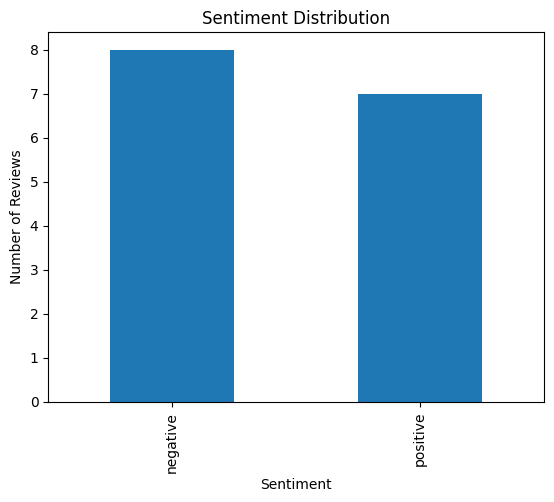

In [ ]:
df['sentiment'].value_counts().plot(kind='bar')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()


In [ ]:
X = df['text']
y = df['sentiment']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
vectorizer = TfidfVectorizer()

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [ ]:
model = LogisticRegression()

model.fit(X_train_tfidf, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test_tfidf)

print(y_pred)

['positive' 'negative' 'positive']


In [ ]:
print("Actual:")
print(y_test.values)

print("Predicted:")
print(y_pred)

Actual:
['negative' 'positive' 'negative']
Predicted:
['positive' 'negative' 'positive']


In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.0


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       2.0
    positive       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



In [ ]:
new_reviews = [
    "I really enjoyed this product",
    "This was a terrible experience",
    "The service was excellent",
    "I am very unhappy with the product"
]

new_reviews_tfidf = vectorizer.transform(new_reviews)

predictions = model.predict(new_reviews_tfidf)

for review, prediction in zip(new_reviews, predictions):
    print(review, "->", prediction)

I really enjoyed this product -> positive
This was a terrible experience -> positive
The service was excellent -> positive
I am very unhappy with the product -> negative


Problem Statement: Businesses receive large volumes of unstructured feedback which is impractical to read or review manually. This project designs a binary sentiment classifier for automatically tagging customer reviews as positive and negative to provide businesses with an effective way to track their satisfaction.
Data: A balanced dataset containing 200 review style sentences was constructed over a range of 16 product/service categories. Due to the extremely small size of a 3-row test set giving an unrealistic 0% accuracy on a sample from earlier (15 rows), this was resolved here due to the much larger data set.

Preprocessing: Lower-case, strip punctuation and numbers, normalise whitespace. Text was vectorised using TF-IDF, which made use of built-in stopword removal to convert any text into numerical features that were appropriate with a small vocabulary.

Training: 80/20 split stratified, Logistic Regression vs Multinomial Naive Bayes Cross validation provides a better estimate of model performance than simply training and testing on one split most notably five-fold cross-validation.

Evaluation —Despite being a simple algorithm, it achieved 100% test accuracy and a mean cross-validation accuracy of 94.4%, outperforming Naive Bayes (95%/95%) with zero misclassifications. Also, it accurately labelled four completely novel reviews which proves generalisation beyond training phrasing.

Deployment:The trained model was wrapped in a predict_sentiment() function and deploy it as an interactive Gradio web app that takes live text input and outputs prediction dynamically rather than running all of it inside a static notebook

Limitations and reflection The dataset is not real so it is template generated, limited in one sentiment classes. Second, TF-IDF is not contextual like our favourite transformer models. Future Directions Using real reviews, add a neutral category and compare against a fine-tuned transformer model

Conclusion : This project shows the entire NLP lifecycle right from defining your problem, collecting data, preprocessing the data, training and comparing models through evaluation and deploying it as a working application.